In [54]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold,RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


In [25]:
data = pd.read_csv(r"C:\Users\USER\Downloads\Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset.csv")

In [26]:
data.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           5000 non-null   int64  
 1   weight        5000 non-null   int64  
 2   height        5000 non-null   int64  
 3   exercise      5000 non-null   object 
 4   sleep         5000 non-null   float64
 5   sugar_intake  5000 non-null   object 
 6   smoking       5000 non-null   object 
 7   alcohol       5000 non-null   object 
 8   married       5000 non-null   object 
 9   profession    5000 non-null   object 
 10  bmi           5000 non-null   float64
 11  health_risk   5000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 468.9+ KB


In [28]:
data.describe()

,age,weight,height,sleep,bmi
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,48.805600,77.359200,171.933200,6.997060,26.84388
std,17.906991,18.714567,15.822225,1.432849,8.25249
min,18.000000,45.000000,145.000000,3.000000,11.40000
25%,34.000000,61.000000,158.000000,6.000000,20.30000
50%,49.000000,77.000000,171.500000,7.000000,26.00000
75%,64.000000,94.000000,186.000000,8.000000,32.40000
max,79.000000,109.000000,199.000000,10.000000,51.40000


In [29]:
data.duplicated().sum()

np.int64(0)

In [30]:
data.isna().sum()

age             0
weight          0
height          0
exercise        0
sleep           0
sugar_intake    0
smoking         0
alcohol         0
married         0
profession      0
bmi             0
health_risk     0
dtype: int64

In [31]:
num_cols = data.select_dtypes(include = ['int64','float64']).columns
cat_cols = data.select_dtypes(include = ['object']).columns

**Checking for outliers**

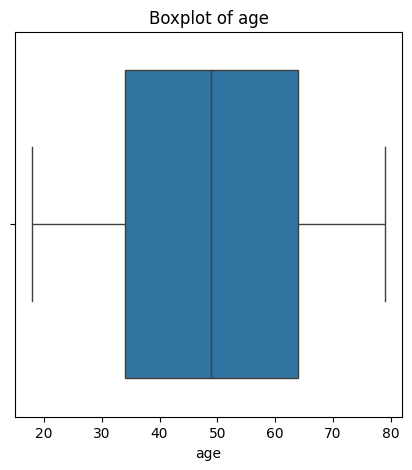

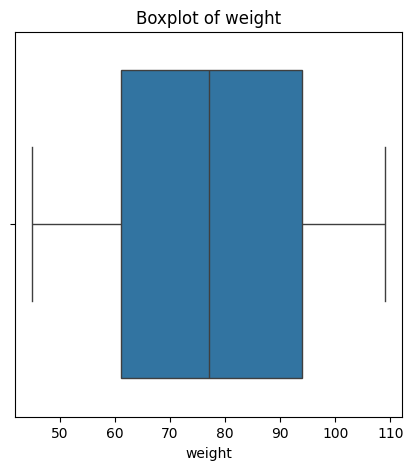

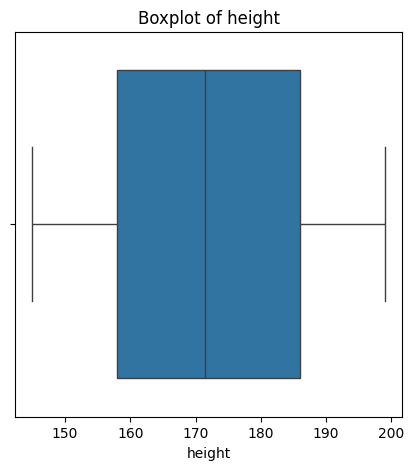

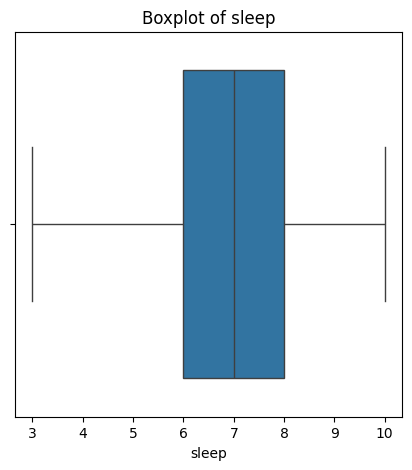

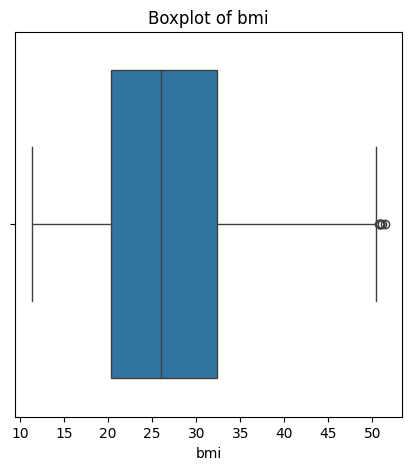

In [20]:
for i in num_cols:
    plt.figure(figsize = (5,5))
    plt.title(f'Boxplot of {i}')
    sns.boxplot(data = data , x = i)
    plt.show()
    

**Exploratory Data Analysis**

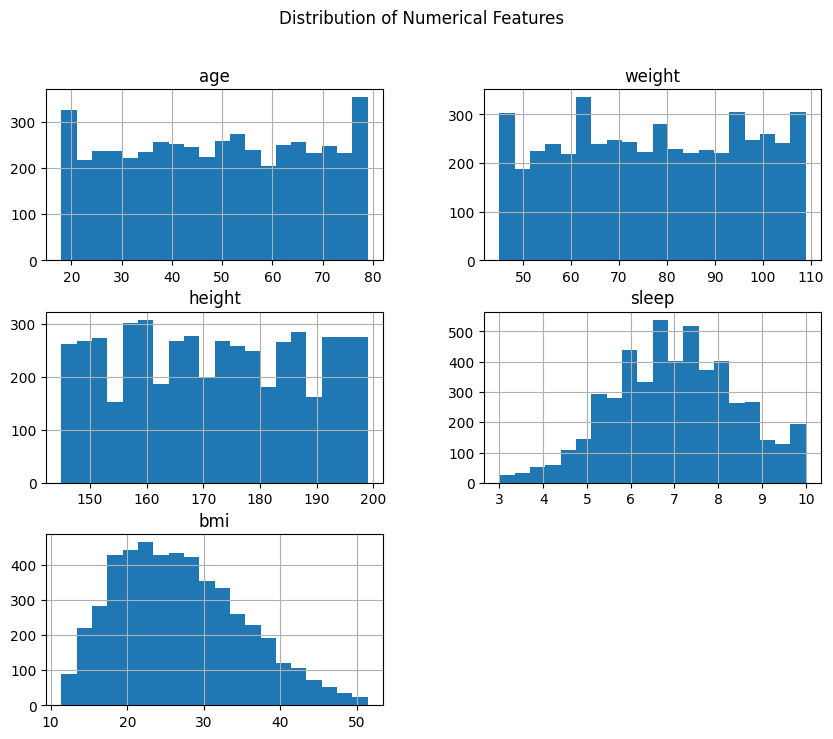

In [32]:
data[num_cols].hist(figsize=(10, 8), bins=20)
plt.suptitle('Distribution of Numerical Features')
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_10652\3858990683.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette="Set2")


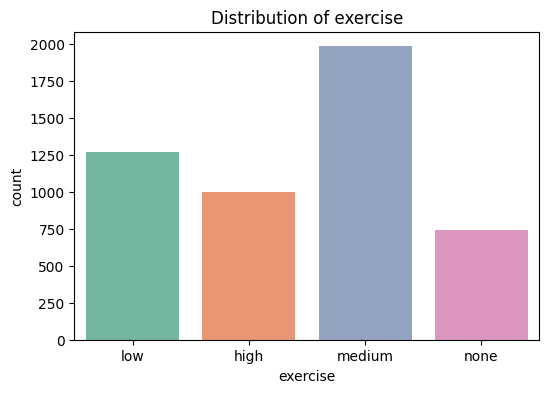

C:\Users\USER\AppData\Local\Temp\ipykernel_10652\3858990683.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette="Set2")


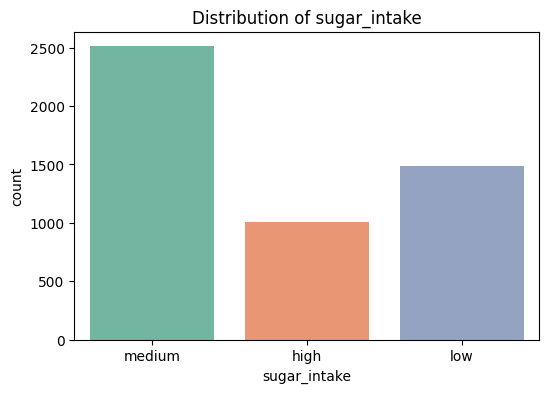

C:\Users\USER\AppData\Local\Temp\ipykernel_10652\3858990683.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette="Set2")


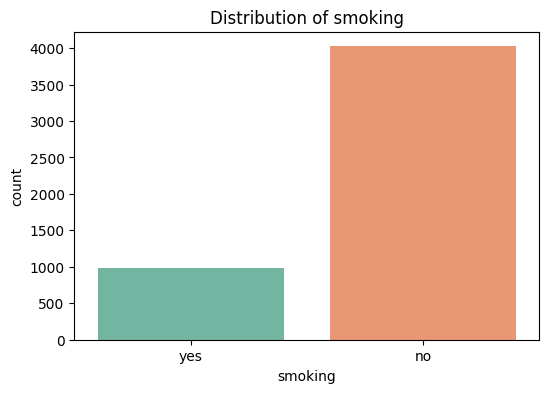

C:\Users\USER\AppData\Local\Temp\ipykernel_10652\3858990683.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette="Set2")


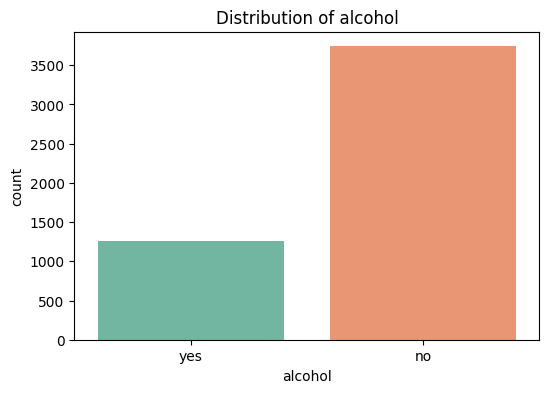

C:\Users\USER\AppData\Local\Temp\ipykernel_10652\3858990683.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette="Set2")


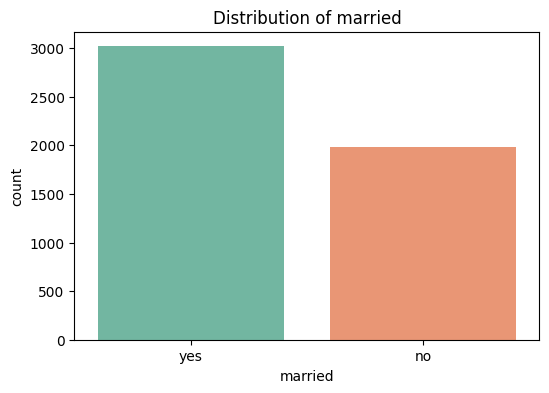

C:\Users\USER\AppData\Local\Temp\ipykernel_10652\3858990683.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette="Set2")


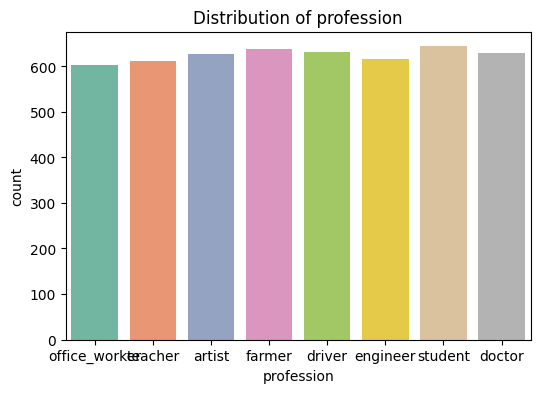

C:\Users\USER\AppData\Local\Temp\ipykernel_10652\3858990683.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette="Set2")


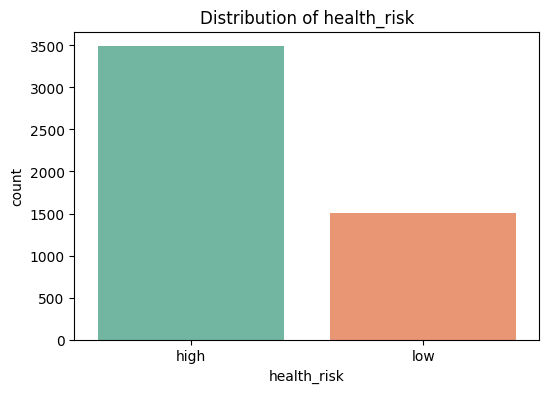

In [33]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=data[col], palette="Set2")
    plt.title(f'Distribution of {col}')
    plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_10652\3118358703.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='health_risk', y=col, data=data, palette="coolwarm")


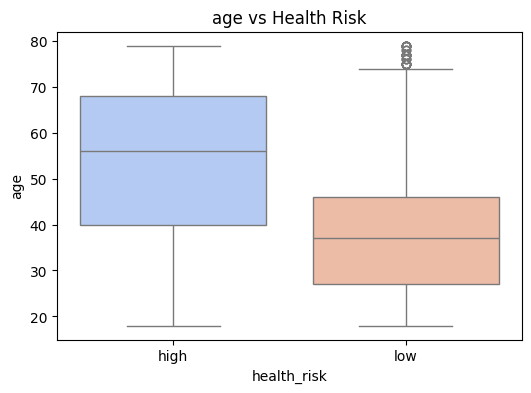

C:\Users\USER\AppData\Local\Temp\ipykernel_10652\3118358703.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='health_risk', y=col, data=data, palette="coolwarm")


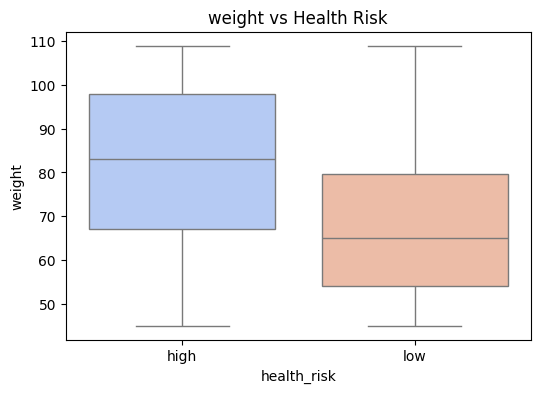

C:\Users\USER\AppData\Local\Temp\ipykernel_10652\3118358703.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='health_risk', y=col, data=data, palette="coolwarm")


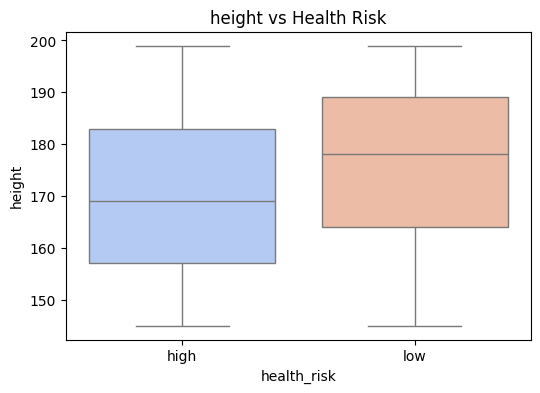

C:\Users\USER\AppData\Local\Temp\ipykernel_10652\3118358703.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='health_risk', y=col, data=data, palette="coolwarm")


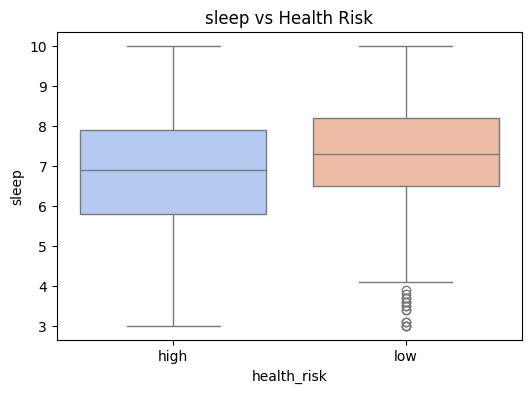

C:\Users\USER\AppData\Local\Temp\ipykernel_10652\3118358703.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='health_risk', y=col, data=data, palette="coolwarm")


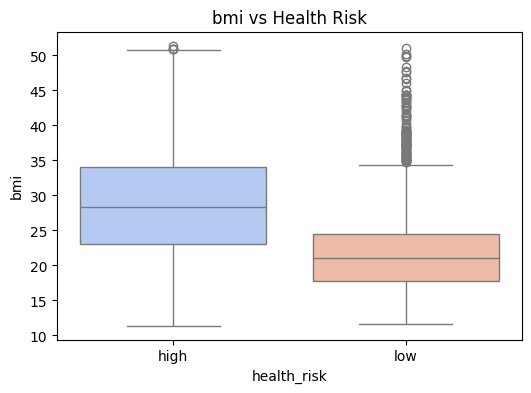

In [34]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='health_risk', y=col, data=data, palette="coolwarm")
    plt.title(f'{col} vs Health Risk')
    plt.show()


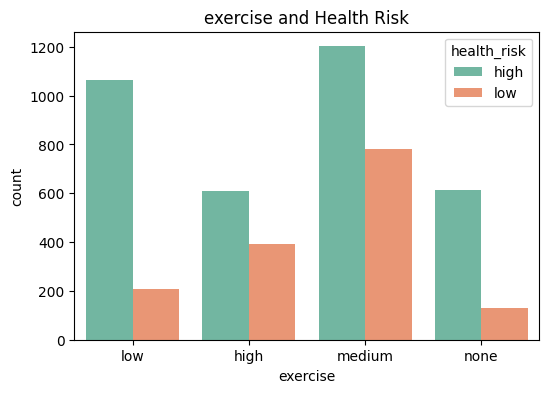

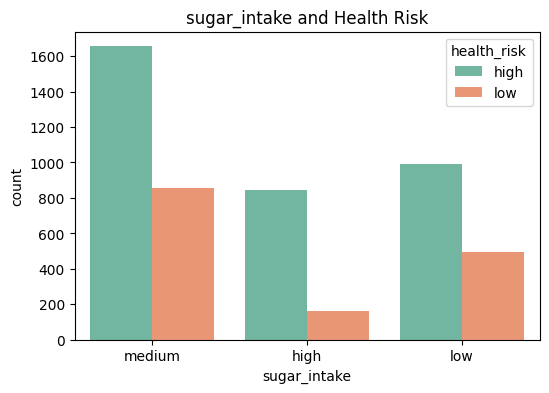

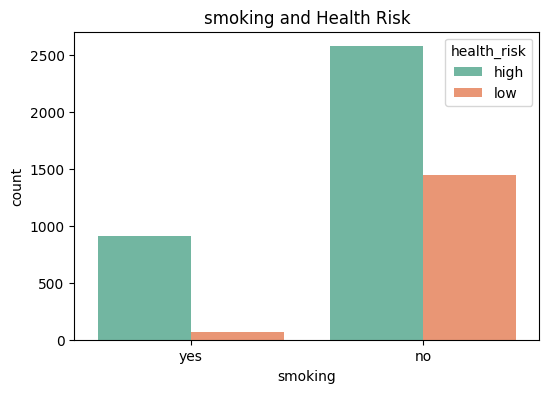

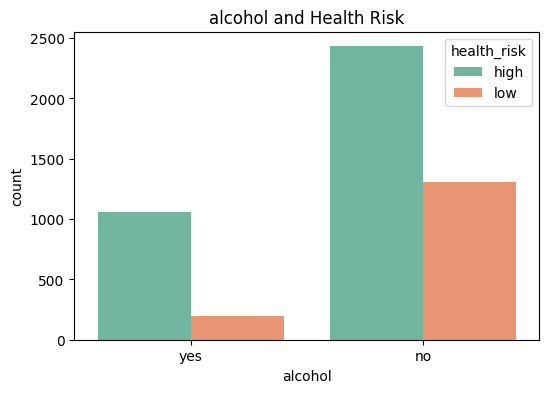

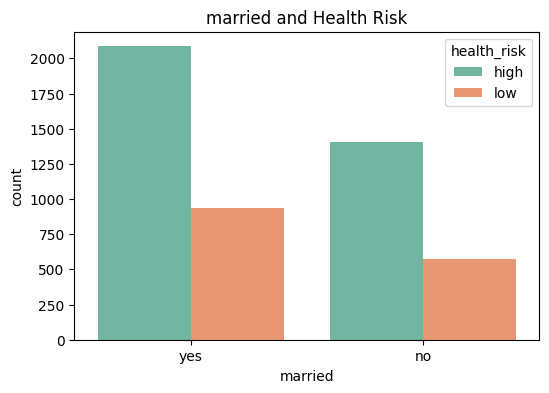

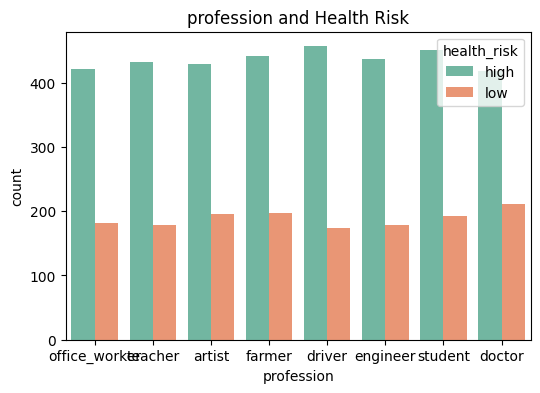

In [35]:
for col in cat_cols[:-1]:  # exclude health_risk
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='health_risk', data=data, palette="Set2")
    plt.title(f'{col} and Health Risk')
    plt.show()


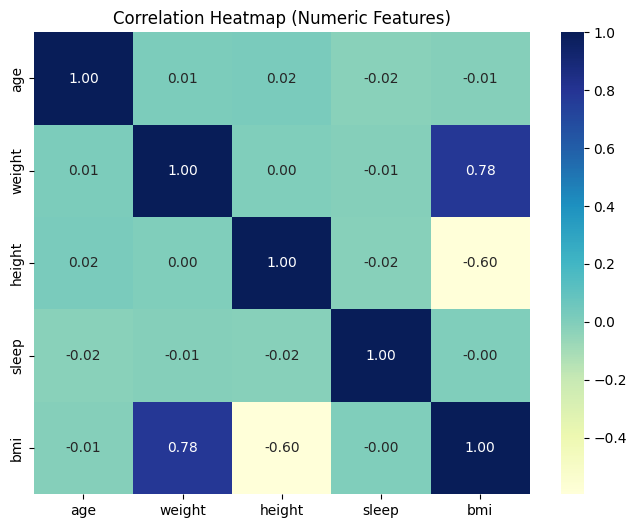

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(data[num_cols].corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


Handle outliers for bmi

In [37]:
Q1 = data['bmi'].quantile(0.25)
Q3 = data['bmi'].quantile(0.75)

IQR = Q3 - Q1

upperbound = Q3 + 1.5*IQR
lowerbound = Q1 - 1.5 * IQR

data['bmi']= data['bmi'].clip(lowerbound, upperbound)

<Axes: xlabel='bmi'>

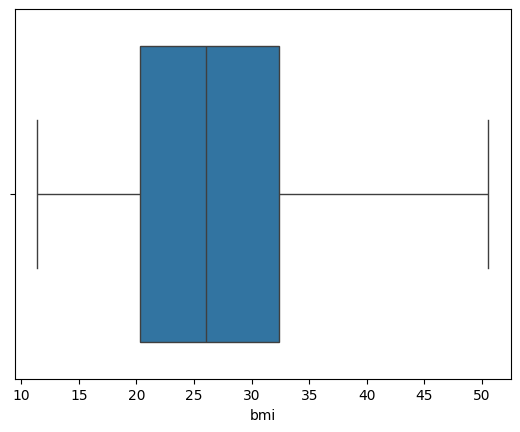

In [39]:
sns.boxplot(data = data, x = 'bmi')

In [55]:
numeric_transformer = Pipeline(steps =[
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown = 'ignore'))
])

# Separate features and target
X = data.drop('health_risk', axis=1)
Y = LabelEncoder().fit_transform(data['health_risk'])

# Identify column types from X (not from data)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Redefine preprocessor using X's column lists
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', cat_transformer, categorical_features)
    ]
)


In [56]:
models = {
    "Random Forest": RandomForestClassifier(random_state = 43),
    "Gradient Boosting": GradientBoostingClassifier(random_state = 43),
    "XGBoost": XGBClassifier(random_state = 43),
    "KNN": KNeighborsClassifier()
}
cv = StratifiedKFold(n_splits = 5, shuffle =True, random_state = 43)

for name, model in models.items():
    pipe = Pipeline([
         ("preprocessor", preprocessor),
         ("classifier", model)
    ])

    scores = cross_val_score(pipe, X, Y, cv =cv, scoring = 'accuracy')

    print(f"\n{name}")
    print("Accuracy Scores:", scores)
    print("Mean accuracy:", scores.mean())
    print("Std Dev:", scores.std())


Random Forest
Accuracy Scores: [0.99  0.991 0.988 0.99  0.994]
Mean accuracy: 0.9905999999999999
Std Dev: 0.001959591794226544

Gradient Boosting
Accuracy Scores: [0.989 0.991 0.989 0.99  0.994]
Mean accuracy: 0.9905999999999999
Std Dev: 0.0018547236990991425

XGBoost
Accuracy Scores: [0.998 0.996 0.997 0.993 0.997]
Mean accuracy: 0.9962
Std Dev: 0.0017204650534085267

KNN
Accuracy Scores: [0.904 0.901 0.897 0.897 0.911]
Mean accuracy: 0.9019999999999999
Std Dev: 0.0052153619241621235


Final Model: XGBoost

In [57]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2 , stratify = Y, random_state = 43)

In [60]:
final_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(random_state = 43))
])

param_dist = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 4, 5, 6, 8, 10],
    'classifier__min_child_weight': [1, 3, 5, 7],
    'classifier__gamma': [0, 0.1, 0.2, 0.3, 0.5],
    'classifier__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__reg_alpha': [0, 0.01, 0.1, 1, 10],
    'classifier__reg_lambda': [0.1, 1, 5, 10]
}

search = RandomizedSearchCV(
    final_pipe,
    param_distributions=param_dist,
    n_iter=20,  # can increase for more thorough search
    scoring='accuracy',
    cv=5,
    verbose=2,
    n_jobs=1,
    random_state=43
)

search.fit(X_train, Y_train)
print("Best Parameters:", search.best_params_)
print("Best Score:", search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0.5, classifier__learning_rate=0.2, classifier__max_depth=10, classifier__min_child_weight=5, classifier__n_estimators=500, classifier__reg_alpha=0.01, classifier__reg_lambda=0.1, classifier__subsample=1.0; total time=   0.1s
[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0.5, classifier__learning_rate=0.2, classifier__max_depth=10, classifier__min_child_weight=5, classifier__n_estimators=500, classifier__reg_alpha=0.01, classifier__reg_lambda=0.1, classifier__subsample=1.0; total time=   0.1s
[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0.5, classifier__learning_rate=0.2, classifier__max_depth=10, classifier__min_child_weight=5, classifier__n_estimators=500, classifier__reg_alpha=0.01, classifier__reg_lambda=0.1, classifier__subsample=1.0; total time=   0.1s
[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0.5, classifier_

In [61]:
best_param = search.best_params_

for para, value in best_param.items():
    print(f"{para}:{value}\n")

classifier__subsample:1.0

classifier__reg_lambda:0.1

classifier__reg_alpha:0.01

classifier__n_estimators:500

classifier__min_child_weight:5

classifier__max_depth:10

classifier__learning_rate:0.2

classifier__gamma:0.5

classifier__colsample_bytree:1.0



In [62]:
final_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(n_estimators = 500, subsample = 1.0 , reg_lambda = 0.1, reg_alpha = 0.01, min_child_weight = 5, max_depth = 10,
     learning_rate = 0.2, gamma = 0.5, colsample_bytree = 1.0, random_state = 43))
])

In [66]:
final_pipe.fit(X_train, Y_train)
pred = final_pipe.predict(X_test)

Y_train_pred = final_pipe.predict(X_train)

print(accuracy_score(Y_train,Y_trai))
print(accuracy_score(Y_test, pred))
print(confusion_matrix(Y_test, pred))

0.99925
0.996
[[695   3]
 [  1 301]]


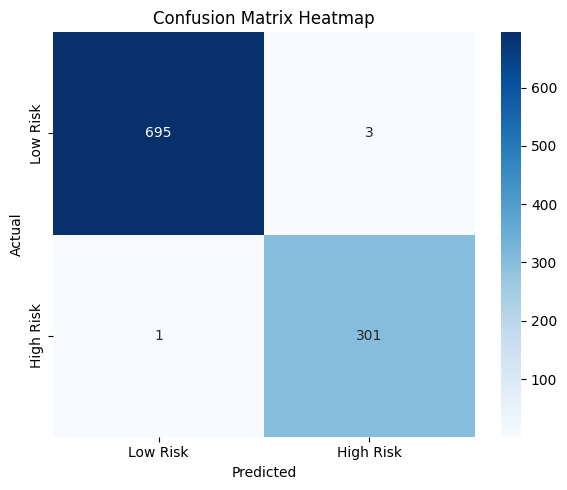

In [69]:
cm = confusion_matrix(Y_test, pred)

# Optional: class labels
labels = ['Low Risk', 'High Risk',]  # adjust based on your classes

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()
